/tmp/ipykernel_17705/496453464.py:81: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  combined_returns = pd.concat(


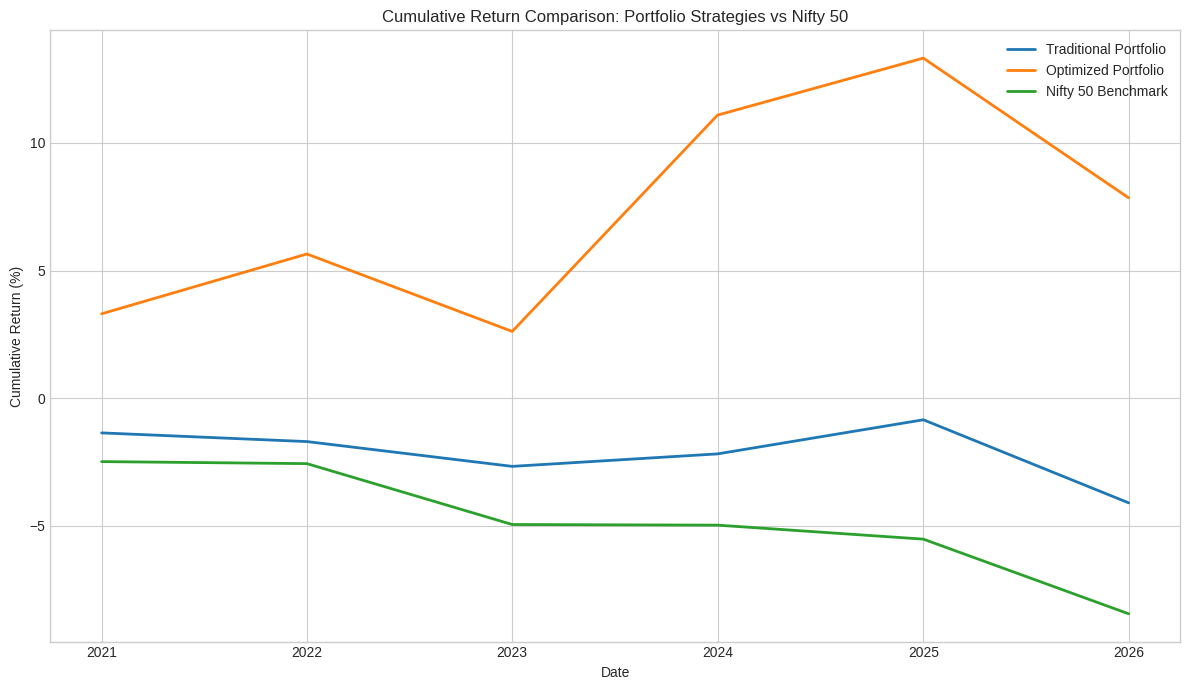

In [ ]:
# ============================================================
# Benchmark Comparison
# Traditional Portfolio vs Optimized Portfolio vs Nifty 50
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")

DATA_DIR = Path("data")
CHART_DIR = Path("charts")
CHART_DIR.mkdir(exist_ok=True)

# ------------------------------------------------------------
# Load Asset Returns
# ------------------------------------------------------------

returns = pd.read_csv(
    "india_equity_returns.csv",
    index_col=0,
    parse_dates=True
)

# ------------------------------------------------------------
# Load Portfolio Weights
# ------------------------------------------------------------

weights = pd.read_csv("portfolio_construction_percent.csv")
weights.set_index("Asset", inplace=True)

equal_weights = weights["Equal_Weight"] / 100
optimized_weights = weights["Optimized_Weight"] / 100

# ------------------------------------------------------------
# Portfolio Daily Returns
# ------------------------------------------------------------

traditional_returns = returns.dot(equal_weights)
optimized_returns = returns.dot(optimized_weights)

# ------------------------------------------------------------
# Load Nifty 50
# ------------------------------------------------------------

benchmark = pd.read_csv(DATA_DIR / "Nifty 50 Historical Data.csv")

benchmark.columns = benchmark.columns.str.strip()

benchmark["Date"] = pd.to_datetime(benchmark["Date"])
benchmark["Price"] = benchmark["Price"].astype(str).str.replace(",", "").astype(float)

benchmark = benchmark.sort_values("Date")
benchmark.set_index("Date", inplace=True)

benchmark_returns = benchmark["Price"].pct_change()

# ------------------------------------------------------------
# Match Date Range
# ------------------------------------------------------------

start = returns.index.min()
end = returns.index.max()

benchmark_returns = benchmark_returns.loc[start:end]

# ------------------------------------------------------------
# Remove NA values
# ------------------------------------------------------------

traditional_returns = traditional_returns.dropna()
optimized_returns = optimized_returns.dropna()
benchmark_returns = benchmark_returns.dropna()

# ------------------------------------------------------------
# Compute Cumulative % Returns
# ------------------------------------------------------------

traditional_cum = ((1 + traditional_returns).cumprod() - 1) * 100
optimized_cum = ((1 + optimized_returns).cumprod() - 1) * 100
benchmark_cum = ((1 + benchmark_returns).cumprod() - 1) * 100

# ------------------------------------------------------------
# Align for plotting
# ------------------------------------------------------------

combined = pd.concat(
    [traditional_cum, optimized_cum, benchmark_cum],
    axis=1
).dropna()

combined.columns = [
    "Traditional Portfolio",
    "Optimized Portfolio",
    "Nifty 50"
]

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(12,7))

plt.plot(combined.index, combined["Traditional Portfolio"], label="Traditional Portfolio", linewidth=2)
plt.plot(combined.index, combined["Optimized Portfolio"], label="Optimized Portfolio", linewidth=2)
plt.plot(combined.index, combined["Nifty 50"], label="Nifty 50 Benchmark", linewidth=2)

plt.title("Cumulative Return Comparison: Portfolio Strategies vs Nifty 50")

plt.xlabel("Date")
plt.ylabel("Cumulative Return (%)")

plt.legend()

plt.tight_layout()

plt.savefig(CHART_DIR / "portfolio_vs_benchmark_returns_percent.png", dpi=300)

plt.show()

In [7]:
print("Nifty total return over dataset:")
print(((1 + benchmark_returns).cumprod().iloc[-1] - 1) * 100)

Nifty total return over dataset:
107.03638993153368
